In [2]:
!pip install tensorflow opencv-python matplotlib tensorflow-io

In [3]:
pip list

Package                               Version             Editable project location
------------------------------------- ------------------- -------------------------
absl-py                               1.4.0
accelerate                            1.8.1
aiofiles                              22.1.0
aiohappyeyeballs                      2.6.1
aiohttp                               3.12.13
aiosignal                             1.3.2
aiosqlite                             0.21.0
alabaster                             1.0.0
albucore                              0.0.24
albumentations                        2.0.8
ale-py                                0.11.1
alembic                               1.16.2
altair                                5.5.0
annotated-types                       0.7.0
annoy                                 1.17.3
ansicolors                            1.1.8
antlr4-python3-runtime                4.9.3
anyio                                 4.9.0
argon2-cffi                     

In [1]:
import os
import tensorflow as tf
from matplotlib import pyplot as plt

2025-08-21 13:49:27.393002: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1755784167.793847    4215 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1755784167.895686    4215 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [2]:
import torch

print("CUDA Available:", torch.cuda.is_available())
print("Device Name:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")

CUDA Available: True
Device Name: Tesla T4


In [3]:
import tensorflow as tf
print("Num GPUs Available:", len(tf.config.list_physical_devices('GPU')))

Num GPUs Available: 2


In [4]:
## Data Loading

In [5]:
CAPUCHIN_FILE = os.path.join('/kaggle/input/z-by-hp-unlocked-challenge-3-signal-processing', 'Parsed_Capuchinbird_Clips', 'XC3776-3.wav')
NOT_CAPUCHIN_FILE = os.path.join('/kaggle/input/z-by-hp-unlocked-challenge-3-signal-processing', 'Parsed_Not_Capuchinbird_Clips', 'afternoon-birds-song-in-forest-0.wav')

In [6]:
import librosa
import tensorflow as tf

def load_wav_16k_mono(filename):
    wav, sr = librosa.load(filename, sr=16000, mono=True)
    return tf.convert_to_tensor(wav, dtype=tf.float32)


In [7]:
wave = load_wav_16k_mono(CAPUCHIN_FILE)
nwave = load_wav_16k_mono(NOT_CAPUCHIN_FILE)

I0000 00:00:1755784207.069513    4215 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1755784207.070317    4215 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


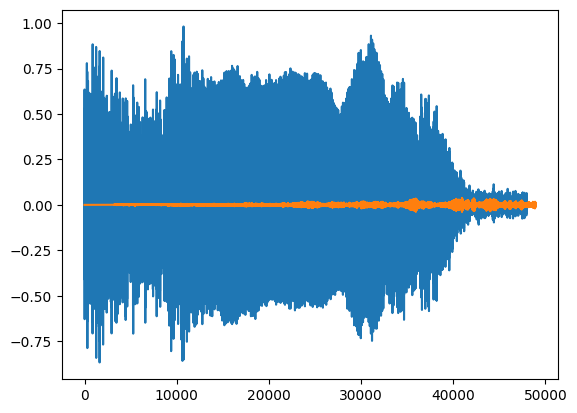

In [8]:
plt.plot(wave)
plt.plot(nwave)
plt.show()

In [9]:
POS = os.path.join('/kaggle/input/z-by-hp-unlocked-challenge-3-signal-processing', 'Parsed_Capuchinbird_Clips')
NEG = os.path.join('/kaggle/input/z-by-hp-unlocked-challenge-3-signal-processing', 'Parsed_Not_Capuchinbird_Clips')

In [10]:
from tensorflow.data import Dataset

In [11]:
pos = Dataset.list_files(POS + "/*.wav")
neg = Dataset.list_files(NEG + "/*.wav")

In [12]:
pos.as_numpy_iterator().next()

b'/kaggle/input/z-by-hp-unlocked-challenge-3-signal-processing/Parsed_Capuchinbird_Clips/XC65195-0.wav'

In [13]:
## now we will be adding the labels according to the file

In [14]:
positives = Dataset.zip((pos, Dataset.from_tensor_slices(tf.ones(len(pos)))))
negatives = Dataset.zip((neg, Dataset.from_tensor_slices(tf.zeros(len(neg)))))
data = positives.concatenate(negatives)

In [15]:
positives.as_numpy_iterator().next()

(b'/kaggle/input/z-by-hp-unlocked-challenge-3-signal-processing/Parsed_Capuchinbird_Clips/XC16803-0.wav',
 1.0)

In [16]:
## now we must make every file equal in the length 
lengths = []
for file in os.listdir(os.path.join('/kaggle/input/z-by-hp-unlocked-challenge-3-signal-processing', 'Parsed_Capuchinbird_Clips')):
    tensor_wave = load_wav_16k_mono(os.path.join('/kaggle/input/z-by-hp-unlocked-challenge-3-signal-processing', 'Parsed_Capuchinbird_Clips', file))
    lengths.append(len(tensor_wave))

In [17]:
mean = tf.reduce_mean(lengths)

In [18]:
mean

<tf.Tensor: shape=(), dtype=int32, numpy=54156>

In [19]:
54156/16000

3.38475

In [20]:
3 * 16000

48000

In [21]:
# hence we will be making each equal to 3 sec

In [22]:
def preprocess(file_path, label): # we are passing label here as we will be passing the whole data pipeline
    wav = load_wav_16k_mono(file_path)

    desired_length = 48000
    wav_length = tf.shape(wav)[0]

    wav = tf.cond(
        wav_length < desired_length,
        lambda: tf.concat([wav, tf.zeros(desired_length - wav_length, dtype=tf.float32)], 0),
        lambda: wav[:desired_length]
    )
    
    spectrogram = tf.signal.stft(wav, frame_length = 320, frame_step = 32)
    spectrogram = tf.abs(spectrogram)
    spectrogram = tf.expand_dims(spectrogram, axis = 2)
    return spectrogram, label

In [23]:
wav = load_wav_16k_mono(CAPUCHIN_FILE)
wav

<tf.Tensor: shape=(48000,), dtype=float32, numpy=
array([-0.05156638,  0.10698248,  0.33992094, ...,  0.0407429 ,
       -0.00256476, -0.02162626], dtype=float32)>

In [24]:
wav = wav[:480000]
zero_padding = tf.zeros([48000] - tf.shape(wav)[0], dtype = tf.float32)
wav = tf.concat([zero_padding, wav], 0)

In [25]:
wav

<tf.Tensor: shape=(48000,), dtype=float32, numpy=
array([-0.05156638,  0.10698248,  0.33992094, ...,  0.0407429 ,
       -0.00256476, -0.02162626], dtype=float32)>

In [26]:
spectrogram = tf.signal.stft(wav, frame_length = 320, frame_step = 32)

In [27]:
spectrogram

<tf.Tensor: shape=(1491, 257), dtype=complex64, numpy=
array([[-3.52083147e-03+0.00000000e+00j, -1.08608603e-03-1.75267458e-04j,
        -4.27640975e-03-3.91407311e-03j, ...,
         9.02446918e-05-5.51044941e-05j, -2.19442882e-06-1.07990665e-04j,
        -7.24941492e-05+0.00000000e+00j],
       [-3.73367220e-03+0.00000000e+00j,  2.41878629e-03+1.37931108e-03j,
         5.27665019e-04-3.50943208e-03j, ...,
         7.40350661e-05-3.86553584e-05j, -7.30532920e-05-4.16346593e-05j,
        -2.51904130e-05+0.00000000e+00j],
       [-2.83098221e-03+0.00000000e+00j, -8.56883824e-04+6.17325306e-04j,
         9.52042639e-03+1.34432316e-03j, ...,
        -1.72932167e-04-5.87422401e-05j, -1.61340839e-04+5.90944546e-06j,
        -7.86781311e-05+0.00000000e+00j],
       ...,
       [ 3.71337682e-03+0.00000000e+00j,  4.90042567e-03-4.67632711e-03j,
        -9.23886150e-03-9.83590260e-03j, ...,
         1.41398050e-05+1.82616059e-04j, -8.14790837e-06-8.17722175e-05j,
        -1.62102282e-04+0.00000

In [28]:
spectrogram = tf.abs(spectrogram)
spectrogram = tf.expand_dims(spectrogram, axis = 2)

In [29]:
spectrogram

<tf.Tensor: shape=(1491, 257, 1), dtype=float32, numpy=
array([[[3.5208315e-03],
        [1.1001370e-03],
        [5.7972101e-03],
        ...,
        [1.0573841e-04],
        [1.0801296e-04],
        [7.2494149e-05]],

       [[3.7336722e-03],
        [2.7844256e-03],
        [3.5488789e-03],
        ...,
        [8.3519022e-05],
        [8.4084648e-05],
        [2.5190413e-05]],

       [[2.8309822e-03],
        [1.0560967e-03],
        [9.6148690e-03],
        ...,
        [1.8263675e-04],
        [1.6144903e-04],
        [7.8678131e-05]],

       ...,

       [[3.7133768e-03],
        [6.7736404e-03],
        [1.3494501e-02],
        ...,
        [1.8316264e-04],
        [8.2177146e-05],
        [1.6210228e-04]],

       [[6.6643208e-04],
        [3.5460822e-03],
        [1.0955372e-02],
        ...,
        [4.1281388e-04],
        [1.5399109e-04],
        [5.8658421e-05]],

       [[5.1540155e-03],
        [4.5302641e-03],
        [5.7057296e-03],
        ...,
        [2.9043853

In [30]:
file_path , label = positives.shuffle(10000).as_numpy_iterator().next()

In [31]:
file_path

b'/kaggle/input/z-by-hp-unlocked-challenge-3-signal-processing/Parsed_Capuchinbird_Clips/XC433953-6.wav'

In [32]:
spectrogram, label = preprocess(file_path, label)

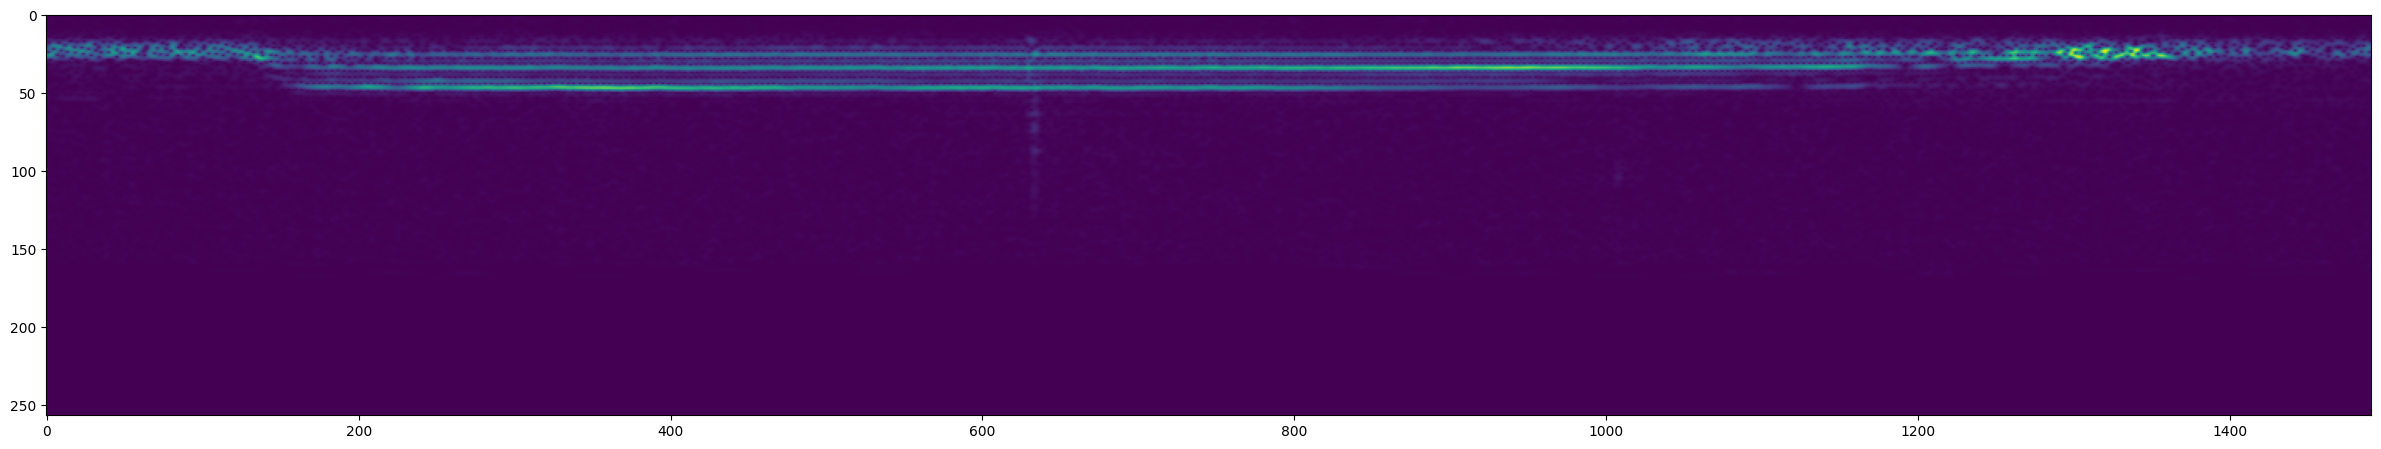

In [33]:
plt.figure(figsize = (30, 20))
plt.imshow(tf.transpose(spectrogram)[0])
plt.show()

In [34]:
# Creating the tensorflow data pipeline 

In [35]:
def load_wav_16k_mono_for_tensor(filename):
    filename = filename.numpy().decode('utf-8')
    wav, sr = librosa.load(filename, sr=16000, mono=True)
    return tf.convert_to_tensor(wav, dtype=tf.float32)

In [36]:
def preprocess_for_tensor(file_path, label):
    wav = tf.py_function(func=load_wav_16k_mono_for_tensor, inp=[file_path], Tout=tf.float32)
    
    desired_length = 48000
    wav_length = tf.shape(wav)[0]
    
    wav = tf.cond(
        wav_length < desired_length,
        lambda: tf.concat([wav, tf.zeros(desired_length - wav_length, dtype=tf.float32)], 0),
        lambda: wav[:desired_length]
    )
    
    spectrogram = tf.signal.stft(wav, frame_length=320, frame_step=32)
    spectrogram = tf.abs(spectrogram)
    spectrogram = tf.expand_dims(spectrogram, axis = 2)
    
    return spectrogram, label

In [37]:
# this map function of tensorflow uses tensors .. hence our string filepath is converted to string ...hence we have to first make them in the form of strings

data = data.map(lambda f, l: preprocess_for_tensor(f, l))

In [38]:
data.as_numpy_iterator().next()

(array([[[6.70379102e-02],
         [8.82471055e-02],
         [1.17421955e-01],
         ...,
         [8.44988390e-05],
         [2.71188019e-05],
         [1.45733356e-05]],
 
        [[5.02413064e-02],
         [8.29944536e-02],
         [1.21006422e-01],
         ...,
         [6.90481465e-05],
         [3.60171070e-05],
         [9.52929258e-06]],
 
        [[1.55650480e-02],
         [6.53483570e-02],
         [1.17229804e-01],
         ...,
         [7.07988947e-05],
         [2.09414939e-05],
         [4.91477549e-05]],
 
        ...,
 
        [[5.96611202e-03],
         [1.88730471e-02],
         [3.52648459e-02],
         ...,
         [5.37507476e-05],
         [1.55331018e-05],
         [2.23517418e-07]],
 
        [[9.51156020e-04],
         [1.02519784e-02],
         [3.68353352e-02],
         ...,
         [3.62758838e-05],
         [1.93123506e-05],
         [9.43243504e-06]],
 
        [[5.54338098e-04],
         [1.02721248e-02],
         [3.93038094e-02],
         

In [39]:
data = data.cache()

In [40]:
data = data.shuffle(1000)

In [41]:
data = data.batch(8)
data = data.prefetch(4)

In [42]:
len(data)

102

In [43]:
train = data.take(75)
test = data.skip(75).take(35)

In [44]:
samples, labels = train.as_numpy_iterator().next()

In [45]:
len(samples) # each batch is now containing 16 spectograms

8

In [46]:
samples.shape

(8, 1491, 257, 1)

In [47]:
# Building the deep learning models

In [48]:
from tensorflow.keras.layers import Conv2D, Dense, Flatten, MaxPooling2D
from tensorflow.keras.models import Sequential

In [49]:
model = Sequential()
model.add(Conv2D(16, (3,3), activation='relu', input_shape=(1491, 257, 1)))
model.add(MaxPooling2D((2, 2)))  
model.add(Conv2D(32, (3,3), activation='relu'))
model.add(MaxPooling2D((2, 2)))  
model.add(Conv2D(64, (3,3), activation='relu'))  
model.add(MaxPooling2D((2, 2)))                 
model.add(Flatten())
model.add(Dense(64, activation='relu'))          
model.add(Dense(1, activation='sigmoid'))

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [50]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [51]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 1489, 255, 16)  │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 744, 127, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 742, 125, 32)   │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 371, 62, 32)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 369, 60, 64)    │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 184, 30, 64)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 353280)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │    22,609,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,633,345 (86.34 MB)

 Trainable params: 22,633,345 (86.34 MB)

 Non-trainable params: 0 (0.00 B)

In [52]:
from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(
    monitor='val_loss',    
    patience=2,           
    restore_best_weights=True, 
    verbose=1
)

In [53]:
if hasattr(train, 'element_spec'):
    print("Train element spec:", train.element_spec)

Train element spec: (TensorSpec(shape=<unknown>, dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.float32, name=None))


In [55]:
samples, labels = test.as_numpy_iterator().next()

In [56]:
labels.shape

(16,)

In [54]:
for batch in train.take(1):
    samples, labels = batch
    print("Sample shape:", samples.shape)
    print("Label shape:", labels.shape)
    print("Label type:", labels.dtype)

def preprocess_batch(samples, labels):
    samples = tf.ensure_shape(samples, (None, 1491, 257, 1))
    return samples, labels

train = train.map(preprocess_batch)
test = test.map(preprocess_batch)

Sample shape: (8, 1491, 257, 1)
Label shape: (8,)
Label type: <dtype: 'float32'>


In [55]:
history = model.fit(train, epochs = 10, validation_data=test, callbacks=[early_stopping])

Epoch 1/10


I0000 00:00:1755784436.222552    4258 service.cc:148] XLA service 0x7f5c480080e0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1755784436.226612    4258 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1755784436.226642    4258 service.cc:156]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1755784436.630537    4258 cuda_dnn.cc:529] Loaded cuDNN version 90300


 4/75 ━━━━━━━━━━━━━━━━━━━━ 3s 49ms/step - accuracy: 0.9167 - loss: 1.0296

I0000 00:00:1755784442.664485    4258 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


75/75 ━━━━━━━━━━━━━━━━━━━━ 16s 92ms/step - accuracy: 0.8783 - loss: 1.7443 - val_accuracy: 0.9571 - val_loss: 0.0841
Epoch 2/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 4s 57ms/step - accuracy: 0.9876 - loss: 0.0656 - val_accuracy: 0.9857 - val_loss: 0.0480
Epoch 3/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 4s 57ms/step - accuracy: 0.9934 - loss: 0.0303 - val_accuracy: 0.9810 - val_loss: 0.0338
Epoch 4/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 4s 56ms/step - accuracy: 0.9949 - loss: 0.0163 - val_accuracy: 1.0000 - val_loss: 0.0013
Epoch 5/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 4s 58ms/step - accuracy: 1.0000 - loss: 0.0011 - val_accuracy: 1.0000 - val_loss: 0.0012
Epoch 6/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 4s 57ms/step - accuracy: 1.0000 - loss: 5.1450e-04 - val_accuracy: 1.0000 - val_loss: 1.6970e-04
Epoch 7/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 4s 55ms/step - accuracy: 1.0000 - loss: 2.6173e-04 - val_accuracy: 1.0000 - val_loss: 0.0011
Epoch 8/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 4s 58ms/step - accuracy: 1.0000 - loss: 7.8801e-04 - val_accuracy: 1.00

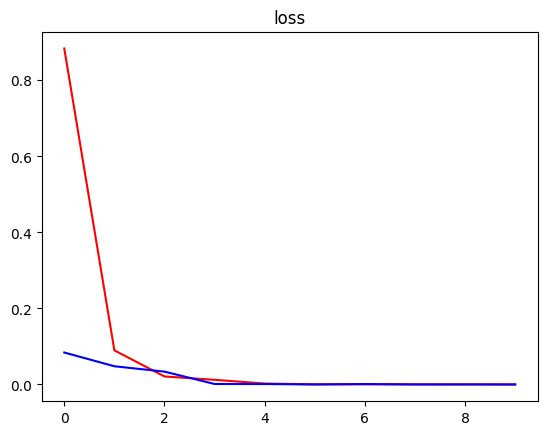

In [56]:
plt.title('loss')
plt.plot(history.history['loss'], 'r')
plt.plot(history.history['val_loss'], 'b')
plt.show()

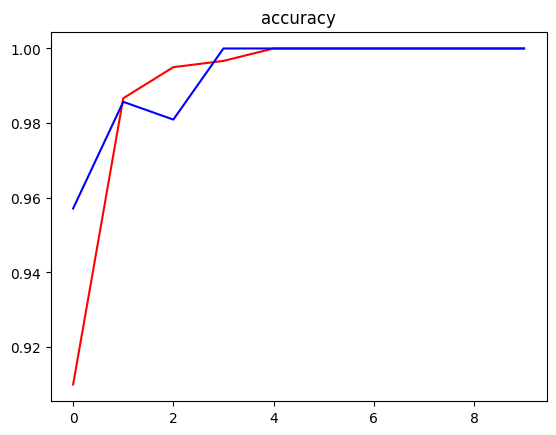

In [57]:
plt.title('accuracy')
plt.plot(history.history['accuracy'], 'r')
plt.plot(history.history['val_accuracy'], 'b')
plt.show()

In [58]:
# making the predictions 

In [59]:
x_test, y_test = test.as_numpy_iterator().next()

In [93]:
x_test.shape

(8, 1491, 257, 1)

In [60]:
y_hat = model.predict(x_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 360ms/step


In [61]:
y_hat

array([[9.8760742e-01],
       [2.9150316e-24],
       [8.3446716e-09],
       [2.6156153e-09],
       [8.7560032e-21],
       [5.9794914e-08],
       [1.9643160e-04],
       [5.8195189e-14]], dtype=float32)

In [62]:
y_hat = [1 if prediction > 0.5 else 0 for prediction in y_hat]

In [63]:
y_hat

[1, 0, 0, 0, 0, 0, 0, 0]

In [64]:
y_test.astype(int)

array([1, 0, 0, 0, 0, 0, 0, 0])

In [65]:
# loading the 3 minutes mp3 files 

In [66]:
def load_mp3_16k_mono(filename):
    audio, _ = librosa.load(filename, sr=16000, mono=True)
    return tf.convert_to_tensor(audio, dtype=tf.float32)

In [67]:
mp3 = os.path.join('/kaggle/input/z-by-hp-unlocked-challenge-3-signal-processing', 'Forest Recordings', 'recording_76.mp3')

In [68]:
wav = load_mp3_16k_mono(mp3)

In [69]:
wav

<tf.Tensor: shape=(2880667,), dtype=float32, numpy=
array([-0.00040277, -0.0010037 , -0.00131391, ...,  0.01296407,
        0.01073097,  0.00860106], dtype=float32)>

In [111]:
audio_slices = tf.keras.utils.timeseries_dataset_from_array(wav, wav, sequence_length=48000, sequence_stride=48000, batch_size=1)

In [112]:
type(audio_slices)

tensorflow.python.data.ops.batch_op._BatchDataset

In [113]:
samples, index = audio_slices.as_numpy_iterator().next()

In [114]:
samples.shape

(1, 48000)

In [115]:
def preprocess_mp3(sample, index):
    sample = sample[0]
    desired_length = 48000
    
    current_length = tf.shape(sample)[0]
    
    sample = tf.cond(
        current_length < desired_length,
        lambda: tf.pad(sample, [[0, desired_length - current_length]]),
        lambda: sample[:desired_length]
    )
    
    spectrogram = tf.signal.stft(sample, frame_length=320, frame_step=32)
    spectrogram = tf.abs(spectrogram)
    spectrogram = tf.expand_dims(spectrogram, axis=2)
    return spectrogram

In [136]:
audio_slices = tf.keras.utils.timeseries_dataset_from_array(wav, wav, sequence_length=48000, sequence_stride=48000, batch_size=1)
audio_slices = audio_slices.map(preprocess_mp3)
audio_slices = audio_slices.batch(64)

In [137]:
samples = audio_slices.as_numpy_iterator().next()

In [138]:
samples.shape

(60, 1491, 257, 1)

In [139]:
yhat = model.predict(audio_slices)
yhat = [1 if prediction > 0.5 else 0 for prediction in yhat]

1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step


In [140]:
len(yhat)

60

In [141]:
yhat

[0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0]

In [133]:
from itertools import groupby

In [134]:
yhat = [key for key, group in groupby(yhat)]
calls = tf.math.reduce_sum(yhat).numpy()

In [135]:
calls

1

In [144]:

i = 0
results = {}
for file in os.listdir('/kaggle/input/z-by-hp-unlocked-challenge-3-signal-processing/Forest Recordings'):
    FILEPATH = os.path.join('/kaggle/input/z-by-hp-unlocked-challenge-3-signal-processing/Forest Recordings', file)
    
    wav = load_mp3_16k_mono(FILEPATH)
    audio_slices = tf.keras.utils.timeseries_dataset_from_array(wav, wav, sequence_length=48000, sequence_stride=48000, batch_size=1)
    audio_slices = audio_slices.map(preprocess_mp3)
    audio_slices = audio_slices.batch(64)

    yhat = model.predict(audio_slices)
    
    results[file] = yhat

    i = i + 1
    if i == 10:
        break

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 386ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 380ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 367ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 383ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 367ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 370ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 366ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 383ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 383ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 373ms/step


In [145]:
results

{'recording_76.mp3': array([[5.1073885e-06],
        [1.8207780e-08],
        [6.5291941e-05],
        [7.1826210e-04],
        [1.9030152e-04],
        [1.3666587e-04],
        [2.0446713e-04],
        [4.6306130e-04],
        [1.3709672e-04],
        [3.5386154e-04],
        [3.2924372e-04],
        [6.8532117e-04],
        [8.1943412e-04],
        [4.9952073e-03],
        [2.7063798e-02],
        [3.4956189e-04],
        [1.0045536e-03],
        [3.6616536e-04],
        [7.7252858e-04],
        [7.3685085e-05],
        [1.2293166e-05],
        [4.1369490e-06],
        [5.0591570e-05],
        [4.3763774e-11],
        [4.7197600e-11],
        [3.4724523e-16],
        [6.2036321e-10],
        [1.7098516e-13],
        [3.3452965e-12],
        [4.2451584e-09],
        [1.0652313e-12],
        [1.9521646e-04],
        [6.9815636e-01],
        [1.6737102e-08],
        [3.1337368e-07],
        [1.3307553e-07],
        [6.1752670e-09],
        [1.2907050e-10],
        [7.1232684e-04],
     

In [146]:
class_preds = {}
for file, logits in results.items():
    class_preds[file] = [1 if prediction > 0.99 else 0 for prediction in logits]
class_preds

{'recording_76.mp3': [0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0],
 'recording_62.mp3': [0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0],
 'recording_48.mp3': [0,
  1,
  1,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  1,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  1,
  1,
  0,
  0,
  1,
  1,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0],
 'recording_44.mp3': [0,
  0,
  0,
  

In [147]:
postprocessed = {}
for file, scores in class_preds.items():
    postprocessed[file] = tf.math.reduce_sum([key for key, group in groupby(scores)]).numpy()
postprocessed

{'recording_76.mp3': 0,
 'recording_62.mp3': 0,
 'recording_48.mp3': 4,
 'recording_44.mp3': 1,
 'recording_45.mp3': 3,
 'recording_06.mp3': 5,
 'recording_43.mp3': 5,
 'recording_68.mp3': 1,
 'recording_95.mp3': 5,
 'recording_17.mp3': 14}